In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("UniversalBank.csv")
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [45]:
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

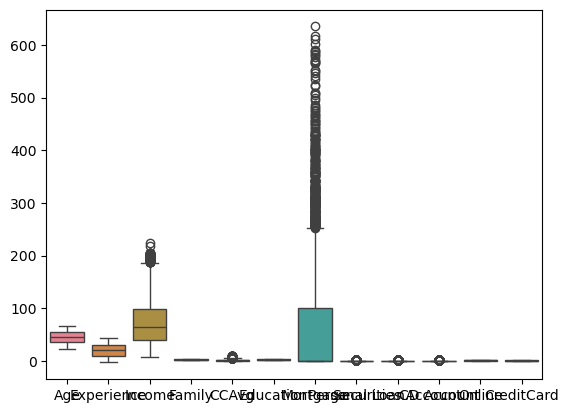

In [46]:
df.drop("ID",axis=1,inplace=True)
df.drop("ZIP Code",axis=1,inplace=True)
sns.boxplot(data=df)
plt.show()

In [47]:
df.describe()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,45.338400,20.104600,73.774200,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,11.463166,11.467954,46.033729,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,23.000000,-3.000000,8.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,35.000000,10.000000,39.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,45.000000,20.000000,64.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,55.000000,30.000000,98.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,67.000000,43.000000,224.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


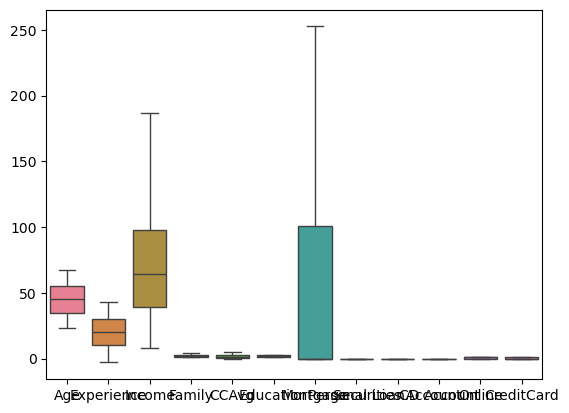

In [48]:
def cap_outliers(column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    # if(column=="Experience"):
    #     lower_bound=0
    return df[column].clip(lower_bound, upper_bound)

df['Income']=cap_outliers('Income')
df['CCAvg']=cap_outliers('CCAvg')
df['Personal Loan']=cap_outliers('Personal Loan')
df['Securities Account']=cap_outliers('Securities Account')
df['CD Account']=cap_outliers('CD Account')
df['Mortgage']=cap_outliers('Mortgage')
df['Experience']=cap_outliers('Experience')
sns.boxplot(data=df)
plt.show()

In [49]:
df.isnull().sum()

Age                   0
Experience            0
Income                0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

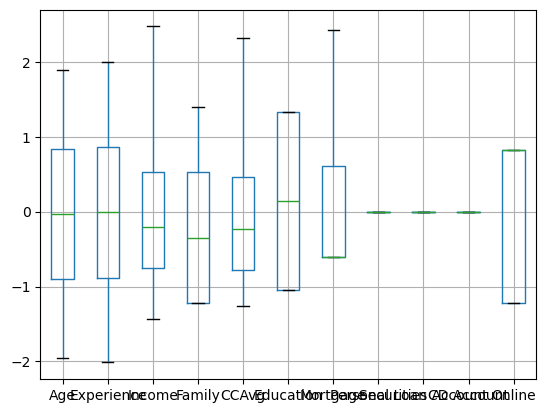

In [50]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled=scaler.fit(df.drop("CreditCard",axis=1)).transform(df.drop('CreditCard',axis=1))
df_scaled=pd.DataFrame(scaled,columns=df.columns[:-1])
df_scaled.boxplot()
plt.show()
x=df_scaled
y=df['CreditCard']
# df.describe()

In [51]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
from sklearn.svm import SVC
model=SVC(kernel='rbf',C=0.5,gamma='scale',degree=3,random_state=42,max_iter=-1)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [53]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.708


In [54]:
from sklearn.svm import SVR
model=SVR()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred=y_pred.round()

In [56]:
from sklearn.metrics import r2_score,mean_squared_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_pred,y_test))

-0.41242937853107353
0.292
